# 05 – Explainability v2 (Updated for v5 Model)

Fixes over the previous version of this notebook:

| \#  | Issue                                                           | Fix                                                                          |
|:-----------------------|:-----------------------|:-----------------------|
| 1   | `Config(**_cfg_raw)` crashed — v5 saved config has 20+ new keys | Graceful loading: filter to known fields, override arch values from artefact |
| 2   | `ContinuousTimeEmbedding` (single sin)                          | `Time2Vec` (multi-frequency learnable)                                       |
| 3   | `OntologyEncoder` hardcoded `conv1`/`conv2`                     | `OntologyEncoder` with `ModuleList(n_layers)`                                |
| 4   | `CardioGNN` used `recency_alpha` + weighted-mean pooling        | `CardioGNN` uses `SequenceAttention` (CLS-query MHA)                         |
| 5   | `SequenceAttributionWrapper` used `model.recency_alpha`         | Uses `model.seq_attn` — correct for v5                                       |
| 6   | `DEMO_test = zeros(N, 0)` zero-size tensor crash                | `zeros(N, max(DEMO_DIM, 1))`                                                 |
| 7   | `torch.load` missing `weights_only=`                            | Added `weights_only=False`                                                   |

All explainability methods unchanged: GNNExplainer, Attention Rollout,
Integrated Gradients (multi-baseline), Discriminative Population IG,
Sequential Counterfactual, Clinical Category Roll-Up, Temporal Decomposition.

## 1. Imports & Setup

In [1]:
import pickle
import random
import math
import warnings
import dataclasses
from pathlib import Path
from dataclasses import dataclass
from collections import defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns
import networkx as nx

import torch
import torch.nn as nn
import torch.nn.functional as F

from torch_geometric.nn import GATv2Conv
from torch_geometric.explain import Explainer, GNNExplainer
from torch_geometric.data import Data

from captum.attr import IntegratedGradients

warnings.filterwarnings("ignore")

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
PLOTS  = Path("outputs/plots/explain_v2")
PLOTS.mkdir(parents=True, exist_ok=True)

c:\Users\marti\Desktop\ST-GNN-Comp\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 2. Config & Artefact Loading

In [2]:
@dataclass
class Config:
    GRAPH_PATH          : str   = r"data/processed/ontology_graph.pkl"
    COHORT_PATH         : str   = r"data/processed/omop_cohort.pkl"
    OUTPUT_DIR          : str   = "outputs"
    TARGET_CONCEPT_ID   : int   = 4329847
    TARGET_CONCEPT_NAME : str   = "Myocardial infarction"
    EMBED_MODEL         : str   = "pritamdeka/S-PubMedBert-MS-MARCO"
    HIDDEN_DIM          : int   = 56
    GAT_LAYERS          : int   = 2
    GAT_HEADS           : int   = 4
    DEMO_DIM            : int   = 0
    DROPOUT             : float = 0.35
    SEED                : int   = 42
    MAX_SEQ_LEN         : int   = 50
    THRESHOLD_FALLBACK  : float = 0.50


with open("outputs/cardiognn_config.pkl", "rb") as f:
    art = pickle.load(f)

# FIX: graceful loading — v5 config has many new keys; filter to known fields
_cfg_raw = art["config"]
if isinstance(_cfg_raw, dict):
    _known = {f.name for f in dataclasses.fields(Config)}
    cfg = Config(**{k: v for k, v in _cfg_raw.items() if k in _known})
else:
    cfg = _cfg_raw

# Override architecture from explicitly saved artefact keys
cfg.HIDDEN_DIM = art.get("hidden_dim", cfg.HIDDEN_DIM)
cfg.GAT_LAYERS = art.get("gat_layers", cfg.GAT_LAYERS)
cfg.GAT_HEADS  = art.get("gat_heads",  cfg.GAT_HEADS)

concept2idx  = art["concept2idx"]
idx2concept  = art["idx2concept"]
id2name      = art["id2name"]
NUM_CONCEPTS = art["num_concepts"]
PAD_IDX      = art["pad_idx"]
EMBED_DIM    = art["embed_dim"]
BEST_THR     = art.get("best_thr_f2", art.get("best_thr_f1", 0.5))
TIME2VEC_K   = art.get("time2vec_k",   8)
SEQ_ATTN_H   = art.get("seq_attn_heads", 4)

C, T, L, Y  = art["C"], art["T"], art["L"], art["Y"]
idx_test     = art["idx_test"]

C_test        = torch.tensor(C[idx_test], dtype=torch.long)
T_test        = torch.tensor(T[idx_test], dtype=torch.float32)
L_test        = torch.tensor(L[idx_test], dtype=torch.long)
Y_test        = torch.tensor(Y[idx_test], dtype=torch.float32)
PAD_MASK_test = (C_test == PAD_IDX)
# FIX: max(DEMO_DIM, 1) prevents zero-size tensor when DEMO_DIM=0
DEMO_test     = torch.zeros(len(Y_test), max(cfg.DEMO_DIM, 1), dtype=torch.float32)

print(f"Test patients : {len(Y_test):,}")
print(f"Positives     : {int(Y_test.sum()):,}  ({100*Y_test.mean():.1f}%)")
print(f"BEST_THR      : {BEST_THR:.3f}")
print(f"Architecture  : HIDDEN_DIM={cfg.HIDDEN_DIM}  GAT_LAYERS={cfg.GAT_LAYERS}  "
      f"GAT_HEADS={cfg.GAT_HEADS}  TIME2VEC_K={TIME2VEC_K}  SEQ_ATTN_H={SEQ_ATTN_H}")

Test patients : 288
Positives     : 24  (8.3%)
BEST_THR      : 0.548
Architecture  : HIDDEN_DIM=56  GAT_LAYERS=2  GAT_HEADS=4  TIME2VEC_K=8  SEQ_ATTN_H=4


## 3. Rebuild Model

In [3]:
from sentence_transformers import SentenceTransformer

with open(cfg.GRAPH_PATH, "rb") as f:
    G = pickle.load(f)

concept_names = [
    id2name.get(idx2concept[i], str(idx2concept[i]))
    for i in range(NUM_CONCEPTS)
]
embedder = SentenceTransformer(cfg.EMBED_MODEL)
CONCEPT_EMBEDDINGS_RAW = embedder.encode(
    concept_names, convert_to_tensor=True,
    show_progress_bar=False, device=str(DEVICE),
).float().to(DEVICE)

src, dst = [], []
for u, v in G.edges():
    src += [concept2idx[u], concept2idx[v]]
    dst += [concept2idx[v], concept2idx[u]]
EDGE_INDEX = torch.tensor([src, dst], dtype=torch.long).to(DEVICE)


# ── v5 Architecture ───────────────────────────────────────────────────────

class Time2Vec(nn.Module):
    """Learnable multi-frequency time encoding (Kazemi et al. 2019)."""
    def __init__(self, hidden_dim, k_periodic=8):
        super().__init__()
        self.linear   = nn.Linear(1, 1)
        self.periodic = nn.Linear(1, k_periodic)
        self.proj     = nn.Linear(1 + k_periodic, hidden_dim)

    def forward(self, time_seqs):
        t = time_seqs.unsqueeze(-1)
        return self.proj(torch.cat(
            [self.linear(t), torch.sin(self.periodic(t))], dim=-1))


class SequenceAttention(nn.Module):
    """CLS-query attentive pooling. NaN guard for fully-masked rows."""
    def __init__(self, hidden_dim, n_heads=4, dropout=0.1):
        super().__init__()
        self.attn  = nn.MultiheadAttention(hidden_dim, n_heads,
                                            dropout=dropout, batch_first=True)
        self.query = nn.Parameter(torch.randn(1, 1, hidden_dim) * 0.02)
        self.norm  = nn.LayerNorm(hidden_dim)
        self.drop  = nn.Dropout(dropout)

    def forward(self, x, pad_mask):
        B = x.shape[0]
        q = self.query.expand(B, -1, -1)
        all_masked = pad_mask.all(dim=1)
        safe_mask  = pad_mask.clone()
        if all_masked.any():
            safe_mask[all_masked] = False
        attended, attn_weights = self.attn(
            q, x, x, key_padding_mask=safe_mask,
            need_weights=True, average_attn_weights=True)
        return self.norm(self.drop(attended.squeeze(1))), attn_weights.squeeze(1)


class OntologyEncoder(nn.Module):
    """N-layer GATv2 with residual connections and x_override support."""
    def __init__(self, raw_embeddings, embed_dim, hidden_dim, heads, n_layers, dropout):
        super().__init__()
        self.register_buffer("raw_embed", raw_embeddings.detach().clone())
        self.proj  = nn.Linear(embed_dim, hidden_dim, bias=False)
        self.drop  = nn.Dropout(dropout)
        dim_per_head = hidden_dim // heads
        self.convs = nn.ModuleList([
            GATv2Conv(hidden_dim, dim_per_head, heads=heads,
                      dropout=dropout, add_self_loops=True)
            for _ in range(n_layers)
        ])
        self.norms = nn.ModuleList([nn.LayerNorm(hidden_dim) for _ in range(n_layers)])

    def forward(self, edge_index, return_attn=False, x_override=None):
        x = F.gelu(self.proj(x_override if x_override is not None else self.raw_embed))
        attn_list = []
        for conv, norm in zip(self.convs, self.norms):
            if return_attn:
                out, (ei, a) = conv(x, edge_index, return_attention_weights=True)
                attn_list.append((ei, a))
            else:
                out = conv(x, edge_index)
            x = norm(self.drop(F.gelu(out)) + x)
        return (x, attn_list) if return_attn else x


class CardioGNN(nn.Module):
    """CardioGNN v5 — Time2Vec + SequenceAttention + N-layer GATv2."""
    def __init__(self, raw_embeddings, embed_dim, hidden_dim,
                 gat_heads, gat_layers, dropout, time2vec_k=8, seq_attn_heads=4):
        super().__init__()
        self.ontology_enc = OntologyEncoder(raw_embeddings, embed_dim, hidden_dim,
                                             gat_heads, gat_layers, dropout)
        self.time_enc  = Time2Vec(hidden_dim, k_periodic=time2vec_k)
        self.seq_attn  = SequenceAttention(hidden_dim, n_heads=seq_attn_heads, dropout=dropout)
        self.drop      = nn.Dropout(dropout)
        in_dim = hidden_dim + (cfg.DEMO_DIM if cfg.DEMO_DIM > 0 else 0)
        self.head = nn.Sequential(
            nn.Linear(in_dim, hidden_dim // 2), nn.GELU(),
            nn.Dropout(dropout), nn.Linear(hidden_dim // 2, 1),
        )

    def _encode_and_pool(self, edge_index, concept_seqs, time_seqs,
                          pad_mask, return_attn=False, x_override=None):
        if return_attn:
            node_emb, attn_layers = self.ontology_enc(
                edge_index, return_attn=True, x_override=x_override)
        else:
            node_emb    = self.ontology_enc(edge_index, x_override=x_override)
            attn_layers = None
        safe_seqs    = concept_seqs.clamp(max=node_emb.shape[0] - 1)
        x            = node_emb[safe_seqs] + self.time_enc(time_seqs)
        patient_rep, event_weights = self.seq_attn(x, pad_mask)
        return self.drop(patient_rep), node_emb, attn_layers, event_weights

    def forward(self, edge_index, concept_seqs, time_seqs,
                seq_lengths, pad_mask, demo_data, x_override=None):
        patient_rep, _, _, _ = self._encode_and_pool(
            edge_index, concept_seqs, time_seqs, pad_mask, x_override=x_override)
        inp = torch.cat([patient_rep, demo_data], dim=-1) if cfg.DEMO_DIM > 0 else patient_rep
        return self.head(inp).squeeze(-1)

    def explain_forward(self, edge_index, concept_seqs, time_seqs,
                        seq_lengths, pad_mask, demo_data, x_override=None):
        patient_rep, node_emb, attn_layers, event_weights = self._encode_and_pool(
            edge_index, concept_seqs, time_seqs, pad_mask,
            return_attn=True, x_override=x_override)
        inp = torch.cat([patient_rep, demo_data], dim=-1) if cfg.DEMO_DIM > 0 else patient_rep
        return self.head(inp).squeeze(-1), node_emb, attn_layers, event_weights


model = CardioGNN(
    CONCEPT_EMBEDDINGS_RAW, EMBED_DIM,
    cfg.HIDDEN_DIM, cfg.GAT_HEADS, cfg.GAT_LAYERS, cfg.DROPOUT,
    time2vec_k=TIME2VEC_K, seq_attn_heads=SEQ_ATTN_H,
).to(DEVICE)
model.load_state_dict(torch.load("outputs/cardiognn_weights.pt",
                                  map_location=DEVICE, weights_only=False))
model.eval()
print(f"Model loaded. Params: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 69186.55it/s]
BertModel LOAD REPORT from: pritamdeka/S-PubMedBert-MS-MARCO
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Model loaded. Params: 71,363


## 4. Shared Utilities

In [4]:
@torch.no_grad()
def get_test_predictions():
    logits = model(EDGE_INDEX,
                   C_test.to(DEVICE), T_test.to(DEVICE),
                   L_test.to(DEVICE), PAD_MASK_test.to(DEVICE),
                   DEMO_test.to(DEVICE))
    return torch.sigmoid(logits).cpu().numpy()

probs_test    = get_test_predictions()
true_pos_idx  = np.where((probs_test >= BEST_THR) & (Y_test.numpy() == 1))[0]
true_neg_idx  = np.where((probs_test <  BEST_THR) & (Y_test.numpy() == 0))[0]
false_pos_idx = np.where((probs_test >= BEST_THR) & (Y_test.numpy() == 0))[0]
false_neg_idx = np.where((probs_test <  BEST_THR) & (Y_test.numpy() == 1))[0]

print(f"TP: {len(true_pos_idx)}  TN: {len(true_neg_idx)}  "
      f"FP: {len(false_pos_idx)}  FN: {len(false_neg_idx)}")


def build_clinical_categories(G, id2name):
    CATEGORY_ROOTS = {
        "Cardiovascular": {"myocardial", "infarction", "heart", "cardiac",
                           "coronary", "angina", "ischemic", "cerebrovascular",
                           "atherosclerosis", "arteriosclerosis", "vascular dementia"},
        "Metabolic":      {"diabetes", "mellitus", "obesity", "cholesterol",
                           "lipid", "metabolic"},
        "Respiratory":    {"bronchus", "lung", "respiratory", "pulmonary",
                           "neoplasm of bronchus"},
        "Neurological":   {"dementia", "alzheimer", "parkinson", "tremor",
                           "akinesia", "cognitive"},
        "Musculoskeletal": {"arthritis", "joint", "osteo", "rheumatoid",
                            "degenerative"},
        "Other":          set(),
    }
    concept_category = {}
    for concept_id, name in id2name.items():
        name_lower = name.lower()
        assigned = False
        for category, keywords in CATEGORY_ROOTS.items():
            if category == "Other":
                continue
            if any(kw in name_lower for kw in keywords):
                concept_category[concept_id] = category
                assigned = True
                break
        if not assigned:
            concept_category[concept_id] = "Other"
    return concept_category

CONCEPT_CATEGORY = build_clinical_categories(G, id2name)
from collections import Counter
cat_counts = Counter(CONCEPT_CATEGORY.values())
print("Category distribution:")
for cat, cnt in sorted(cat_counts.items(), key=lambda x: -x[1]):
    print(f"  {cat:20s}: {cnt}")


def draw_ontology_graph(sub, weight_key="weight", title="", figsize=(14, 9),
                        colorbar_label="Edge importance", save_path=None):
    fig, ax = plt.subplots(figsize=figsize)
    self_loops = list(nx.selfloop_edges(sub))
    sub.remove_edges_from(self_loops)
    if sub.number_of_edges() == 0:
        ax.text(0.5, 0.5, "No edges to display", ha="center", va="center",
                transform=ax.transAxes, fontsize=12)
        ax.axis("off")
        plt.tight_layout()
        if save_path: plt.savefig(save_path, dpi=220, bbox_inches="tight")
        plt.show()
        return
    try:
        pos = nx.kamada_kawai_layout(sub, scale=4.0)
    except Exception:
        pos = nx.spring_layout(sub, seed=42, k=3.0, scale=4.0)
    def node_color(name):
        n = name.lower()
        if any(k in n for k in ["myocardial", "infarction", "cerebral infarc"]):
            return "#c0392b"
        if any(k in n for k in ["angina", "heart", "cardiac", "coronary", "ischemic"]):
            return "#27ae60"
        return "#2980b9"
    node_colors = [node_color(n) for n in sub.nodes()]
    weights = np.array([sub[u][v].get(weight_key, 0.0) for u, v in sub.edges()])
    w_min, w_max = weights.min(), weights.max()
    w_norm = (weights - w_min) / (w_max - w_min + 1e-9)
    cmap = plt.cm.RdYlBu_r
    edge_colors = cmap(w_norm)
    nx.draw_networkx_nodes(sub, pos, ax=ax, node_color=node_colors,
                           node_size=2800, alpha=0.92)
    for (u, v), color in zip(sub.edges(), edge_colors):
        nx.draw_networkx_edges(sub, pos, ax=ax, edgelist=[(u, v)],
                               edge_color=[color], width=2.0, arrows=True,
                               arrowsize=16, connectionstyle="arc3,rad=0.12",
                               min_source_margin=25, min_target_margin=25)
    nx.draw_networkx_labels(sub, pos, ax=ax, font_size=11, font_color="black",
                            font_weight="bold", verticalalignment="bottom",
                            bbox=dict(boxstyle="round,pad=0.18", fc="white",
                                      ec="none", alpha=0.75))
    weights_arr = np.array([sub[u][v].get(weight_key, 0.0) for u, v in sub.edges()])
    sm = plt.cm.ScalarMappable(cmap=cmap,
                                norm=plt.Normalize(vmin=weights_arr.min(),
                                                   vmax=weights_arr.max()))
    sm.set_array([])
    plt.colorbar(sm, ax=ax, fraction=0.025, pad=0.01, shrink=0.5,
                 label=colorbar_label)
    ax.set_title(title, fontsize=11, pad=12)
    ax.axis("off")
    plt.tight_layout()
    if save_path: plt.savefig(save_path, dpi=220, bbox_inches="tight")
    plt.show()

TP: 23  TN: 38  FP: 226  FN: 1
Category distribution:
  Cardiovascular      : 13
  Other               : 6
  Neurological        : 6
  Musculoskeletal     : 3
  Metabolic           : 1
  Respiratory         : 1


## 5A. GNNExplainer

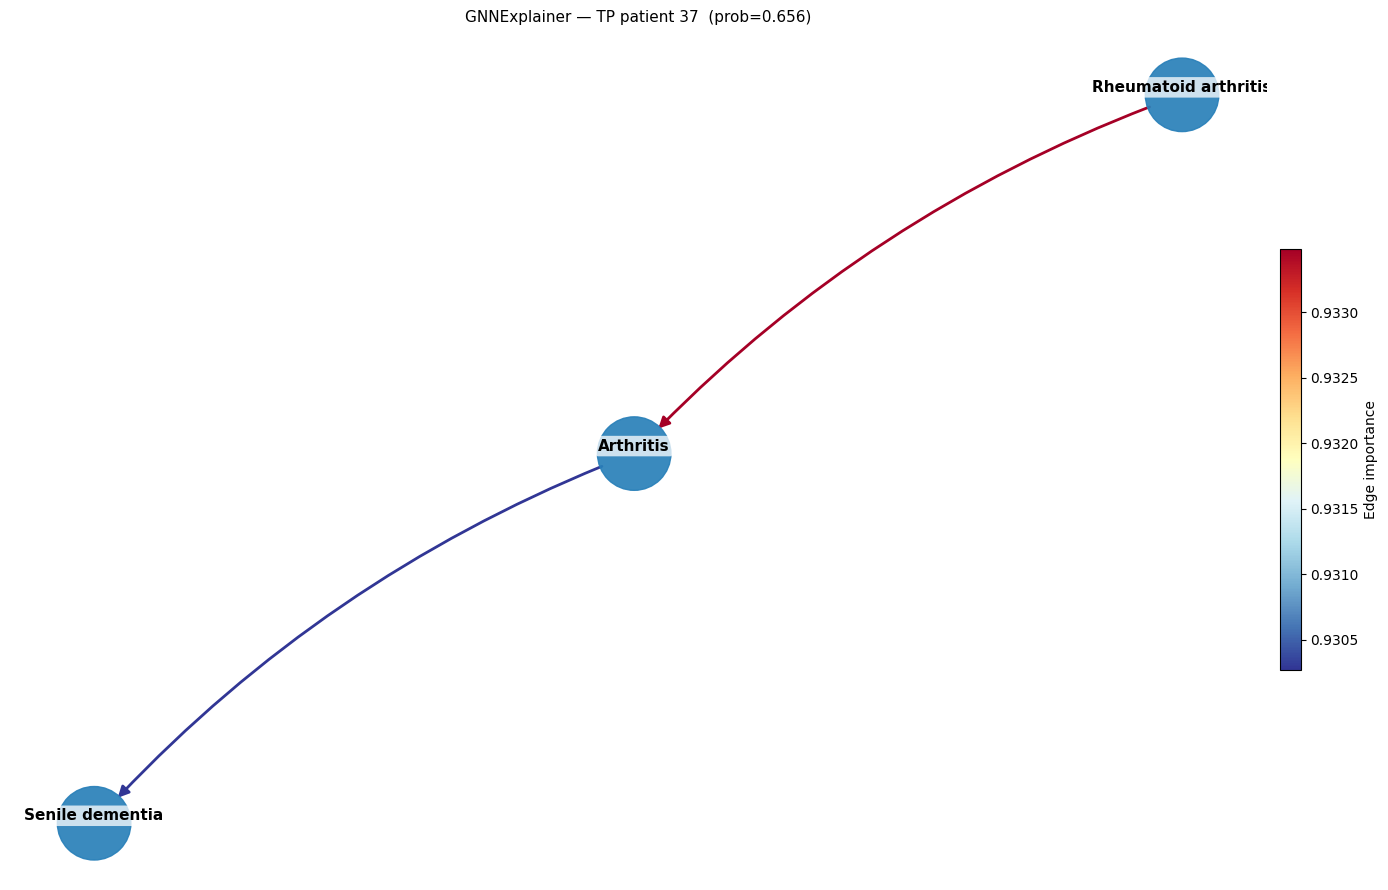

GNNExplainer TP patient 37:  2 important edges found


In [5]:
class GNNExplainWrapper(nn.Module):
    """
    Wrapper for GNNExplainer: model(x, edge_index) → scalar logit.
    x_override allows GNNExplainer to perturb node features safely.
    """
    def __init__(self, cardiognn_model):
        super().__init__()
        self.model = cardiognn_model
        self._c = self._t = self._l = self._pm = self._dm = None

    def set_patient(self, c, t, l, pm, dm):
        self._c  = c.unsqueeze(0).to(DEVICE)
        self._t  = t.unsqueeze(0).to(DEVICE)
        self._l  = l.unsqueeze(0).to(DEVICE)
        self._pm = pm.unsqueeze(0).to(DEVICE)
        self._dm = dm.unsqueeze(0).to(DEVICE)

    def forward(self, x, edge_index):
        logit = self.model(
            edge_index, self._c, self._t, self._l,
            self._pm, self._dm, x_override=x)
        return logit.unsqueeze(-1)


gnn_wrapper = GNNExplainWrapper(model)

explainer = Explainer(
    model=gnn_wrapper,
    algorithm=GNNExplainer(epochs=200),
    explanation_type="model",
    node_mask_type="attributes",
    edge_mask_type="object",
    model_config=dict(mode="binary_classification",
                      task_level="graph", return_type="raw"),
)

x_input = CONCEPT_EMBEDDINGS_RAW.clone().to(DEVICE)

if len(true_pos_idx) > 0:
    pi = true_pos_idx[0]
    gnn_wrapper.set_patient(
        C_test[pi], T_test[pi], L_test[pi], PAD_MASK_test[pi], DEMO_test[pi])
    target = torch.tensor([int(Y_test[pi].item())], dtype=torch.long).to(DEVICE)
    explanation = explainer(x_input, EDGE_INDEX, target=target)

    edge_mask = explanation.edge_mask.cpu().numpy()
    ei_np     = EDGE_INDEX.cpu().numpy()

    sub_gnn = nx.DiGraph()
    for i in range(len(edge_mask)):
        if i >= ei_np.shape[1] or edge_mask[i] < 0.1:
            continue
        src_c = idx2concept.get(int(ei_np[0, i]))
        dst_c = idx2concept.get(int(ei_np[1, i]))
        if src_c and dst_c:
            sub_gnn.add_edge(id2name.get(src_c, str(src_c)),
                             id2name.get(dst_c, str(dst_c)),
                             weight=float(edge_mask[i]))

    if sub_gnn.number_of_edges() > 0:
        draw_ontology_graph(
            sub_gnn, title=f"GNNExplainer — TP patient {pi}  (prob={probs_test[pi]:.3f})",
            save_path=PLOTS / "gnnexplainer_tp.png")

    print(f"GNNExplainer TP patient {pi}:  {sub_gnn.number_of_edges()} important edges found")

## 5B. Attention Rollout

Attention rollout with residual correction across all GAT layers.
Averages attention weights across heads, then propagates layer-by-layer.

In [6]:
@torch.no_grad()
def attention_rollout(patient_idx):
    """
    Attention rollout: propagate GAT attention through all layers
    with residual identity correction.
    Returns per-concept importance dict.
    """
    c  = C_test[patient_idx].unsqueeze(0).to(DEVICE)
    t  = T_test[patient_idx].unsqueeze(0).to(DEVICE)
    l  = L_test[patient_idx].unsqueeze(0).to(DEVICE)
    pm = PAD_MASK_test[patient_idx].unsqueeze(0).to(DEVICE)
    dm = DEMO_test[patient_idx].unsqueeze(0).to(DEVICE)

    _, node_emb, attn_layers, _ = model.explain_forward(EDGE_INDEX, c, t, l, pm, dm)

    N = NUM_CONCEPTS
    # Build dense attention matrices per layer
    rollout = np.eye(N)
    for ei_l, alpha_l in attn_layers:
        A = np.zeros((N, N))
        alpha_mean = alpha_l.mean(dim=-1).cpu().numpy()
        src_np = ei_l[0].cpu().numpy()
        dst_np = ei_l[1].cpu().numpy()
        for j in range(len(alpha_mean)):
            s, d = int(src_np[j]), int(dst_np[j])
            if s < N and d < N:
                A[d, s] += alpha_mean[j]
        # Normalise rows
        row_sums = A.sum(axis=1, keepdims=True) + 1e-9
        A_norm = A / row_sums
        # Residual correction: A_hat = 0.5*I + 0.5*A
        A_hat = 0.5 * np.eye(N) + 0.5 * A_norm
        rollout = A_hat @ rollout

    # Aggregate rollout importance for patient's concepts
    mask_np = PAD_MASK_test[patient_idx].numpy()
    result = {}
    for i in range(len(mask_np)):
        if mask_np[i]: continue
        cidx = C_test[patient_idx][i].item()
        if cidx >= N: continue
        # Importance = total attention received by this concept across all nodes
        importance = rollout[:, cidx].sum()
        result[cidx] = result.get(cidx, 0) + float(importance)

    return result


if len(true_pos_idx) > 0:
    pi = true_pos_idx[0]
    rollout_importance = attention_rollout(pi)
    rollout_sorted = sorted(rollout_importance.items(),
                             key=lambda x: x[1], reverse=True)
    print(f"Attention Rollout — TP patient {pi} (prob={probs_test[pi]:.3f}):")
    for cidx, imp in rollout_sorted[:10]:
        cid = idx2concept[cidx]
        print(f"  {id2name.get(cid, str(cid)):40s}  {imp:.4f}")

Attention Rollout — TP patient 37 (prob=0.656):
  Arthritis                                 1.9189


## 5C. Integrated Gradients (Multi-Baseline)

FIX v5: `SequenceAttributionWrapper` now uses `model.seq_attn` instead
of the removed `model.recency_alpha` weighted-mean pooling.

In [7]:
class SequenceAttributionWrapper(nn.Module):
    """
    Captum wrapper for IG over concept embedding sequences.
    FIX: uses model.seq_attn (SequenceAttention) — recency_alpha removed in v5.
    """
    def __init__(self, cardiognn_model):
        super().__init__()
        self.model = cardiognn_model

    def forward(self, emb_seq, time_seqs, pad_mask, demo):
        x = emb_seq + self.model.time_enc(time_seqs)      # [1, T, H]
        patient_rep, _ = self.model.seq_attn(x, pad_mask) # [1, H]
        patient_rep = self.model.drop(patient_rep)
        inp = (torch.cat([patient_rep, demo], dim=-1)
               if cfg.DEMO_DIM > 0 else patient_rep)
        return self.model.head(inp).squeeze(-1)


attr_wrapper = SequenceAttributionWrapper(model).to(DEVICE)
attr_wrapper.eval()


def build_baseline_embedding(indices, node_emb):
    all_embs = []
    for idx in indices:
        c  = C_test[idx].to(DEVICE)
        pm = PAD_MASK_test[idx]
        safe_c = c.clamp(max=node_emb.shape[0] - 1)
        emb = node_emb[safe_c]
        mask = (~pm).float().unsqueeze(-1).to(DEVICE)
        all_embs.append((emb * mask).cpu())
    stacked = torch.stack(all_embs)
    return stacked.mean(dim=0).to(DEVICE)


def attribute_patient_sequence(patient_idx, baseline_type="both"):
    """IG attribution with zero, marginal, and healthy baselines."""
    c  = C_test[patient_idx].to(DEVICE)
    t  = T_test[patient_idx].unsqueeze(0).to(DEVICE)
    pm = PAD_MASK_test[patient_idx].unsqueeze(0).to(DEVICE)
    dm = DEMO_test[patient_idx].unsqueeze(0).to(DEVICE)

    node_emb = model.ontology_enc(EDGE_INDEX).detach()
    safe_c   = c.clamp(max=node_emb.shape[0] - 1)
    emb_seq  = node_emb[safe_c].unsqueeze(0)

    baselines = {}
    if baseline_type in ("zero", "both"):
        baselines["zero"] = torch.zeros_like(emb_seq)
    if baseline_type in ("marginal", "both"):
        rng = np.random.RandomState(42)
        sample_idx = rng.choice(len(Y_test), size=min(100, len(Y_test)), replace=False)
        baselines["marginal"] = build_baseline_embedding(sample_idx, node_emb).unsqueeze(0)
    if baseline_type in ("healthy", "both"):
        healthy_idx = true_neg_idx[:min(100, len(true_neg_idx))]
        if len(healthy_idx) > 0:
            baselines["healthy"] = build_baseline_embedding(healthy_idx, node_emb).unsqueeze(0)

    all_importance = []
    for bname, baseline in baselines.items():
        emb_input = emb_seq.clone().requires_grad_(True)
        ig = IntegratedGradients(attr_wrapper)
        attr = ig.attribute(
            emb_input, baselines=baseline,
            additional_forward_args=(t, pm, dm), n_steps=50)
        importance = attr.squeeze(0).norm(dim=-1).detach().cpu().numpy()
        all_importance.append(importance)

    avg_importance = np.mean(all_importance, axis=0)
    mask_np = PAD_MASK_test[patient_idx].numpy()

    results = []
    for i, (imp, is_pad) in enumerate(zip(avg_importance, mask_np)):
        if is_pad: continue
        concept_raw = C_test[patient_idx][i].item()
        if concept_raw >= NUM_CONCEPTS: continue
        concept_id = idx2concept[concept_raw]
        results.append({
            "position":     i,
            "concept_id":   concept_id,
            "concept_name": id2name.get(concept_id, str(concept_id)),
            "attribution":  float(imp),
            "category":     CONCEPT_CATEGORY.get(concept_id, "Other"),
        })

    return pd.DataFrame(results).sort_values("attribution", ascending=False)


if len(true_pos_idx) > 0:
    pi = true_pos_idx[0]
    ig_df = attribute_patient_sequence(pi, baseline_type="both")
    print(f"IG (multi-baseline) — TP patient {pi}, prob={probs_test[pi]:.3f}:")
    print(ig_df.head(10).to_string(index=False))

IG (multi-baseline) — TP patient 37, prob=0.656:
 position  concept_id concept_name  attribution        category
       49     4291025    Arthritis      0.21106 Musculoskeletal


## 5D. Discriminative Population Attribution (TP vs TN)

Running IG over true positives...
Running IG over true negatives...

Top discriminative concepts (TP − TN):
                   concept  mean_attr_TP  mean_attr_TN  discriminative_score
           Angina pectoris      0.210387      0.000000              0.210387
                 Arthritis      0.166630      0.000000              0.166630
                       CDI      0.092847      0.000000              0.092847
                  Dementia      0.087987      0.000000              0.087987
Primary malignant neoplasm      0.136977      0.111138              0.025838
           Mental disorder      0.147429      0.196128             -0.048699


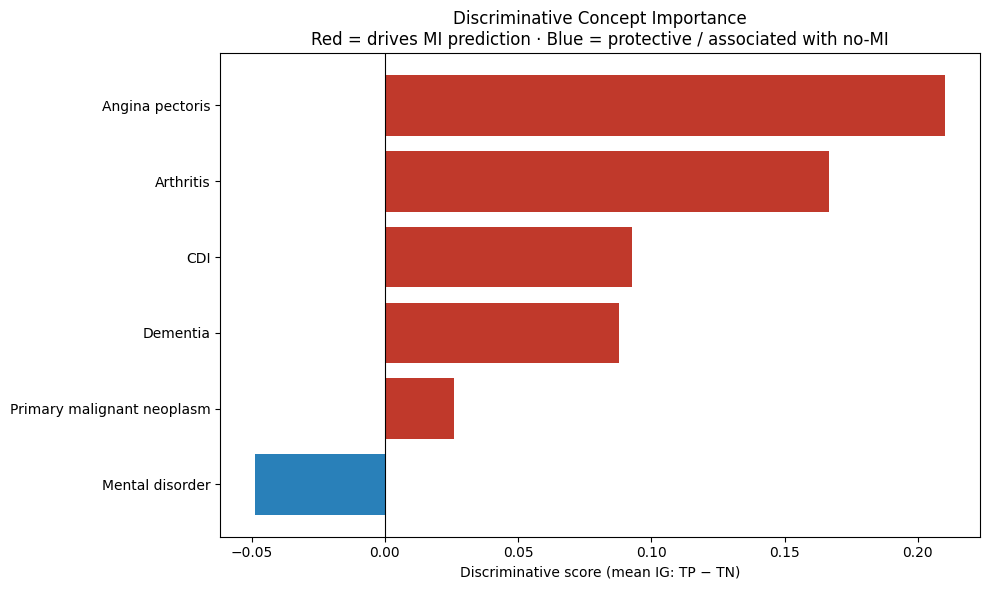

In [8]:
def population_ig_analysis(pos_indices, neg_indices, max_patients=50):
    def collect_attributions(indices, label):
        attr_dict = defaultdict(list)
        for pi in indices[:max_patients]:
            df_i = attribute_patient_sequence(pi, baseline_type="both")
            for _, row in df_i.iterrows():
                attr_dict[row["concept_name"]].append(row["attribution"])
        return {k: np.mean(v) for k, v in attr_dict.items()}

    print("Running IG over true positives...")
    tp_attr = collect_attributions(pos_indices, "TP")
    print("Running IG over true negatives...")
    tn_attr = collect_attributions(neg_indices, "TN")

    all_concepts = set(tp_attr.keys()) | set(tn_attr.keys())
    rows = []
    for c in all_concepts:
        tp_val = tp_attr.get(c, 0.0)
        tn_val = tn_attr.get(c, 0.0)
        rows.append({
            "concept": c,
            "mean_attr_TP": tp_val,
            "mean_attr_TN": tn_val,
            "discriminative_score": tp_val - tn_val,
        })
    return pd.DataFrame(rows).sort_values("discriminative_score", ascending=False)


disc_df = population_ig_analysis(true_pos_idx, true_neg_idx, max_patients=50)
print("\nTop discriminative concepts (TP − TN):")
print(disc_df.head(12).to_string(index=False))

fig, ax = plt.subplots(figsize=(10, 6))
top_disc = disc_df.head(12).iloc[::-1]
colors = ["#c0392b" if v > 0 else "#2980b9" for v in top_disc["discriminative_score"]]
ax.barh(top_disc["concept"], top_disc["discriminative_score"], color=colors)
ax.axvline(0, color="black", lw=0.8)
ax.set_xlabel("Discriminative score (mean IG: TP − TN)")
ax.set_title("Discriminative Concept Importance\n"
             "Red = drives MI prediction · Blue = protective / associated with no-MI")
plt.tight_layout()
plt.savefig(PLOTS / "discriminative_ig.png", dpi=220, bbox_inches="tight")
plt.show()

## 5E. Sequential Greedy Counterfactual

Sequential counterfactual for TP patient 37:
  Original prob : 0.656
  Edges removed : 3
    Step 1: remove Vascular dementia → Arthritis  → prob=0.654
    Step 2: remove Senile dementia → Arthritis  → prob=0.652
    Step 3: remove Rheumatoid arthritis → Arthritis  → prob=0.649


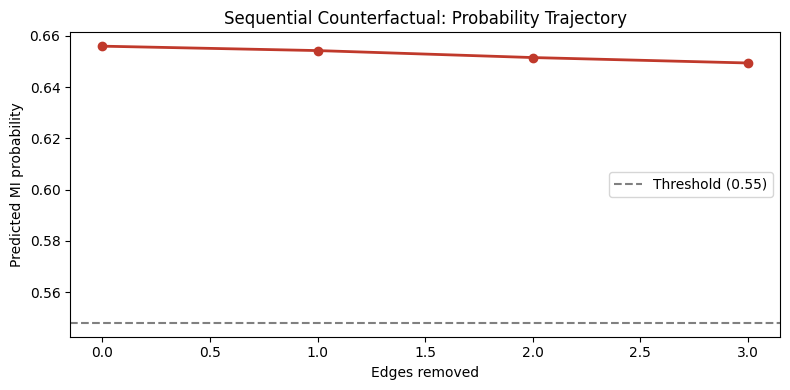

In [9]:
@torch.no_grad()
def sequential_counterfactual(patient_idx, prob_threshold=None):
    if prob_threshold is None:
        prob_threshold = BEST_THR

    c  = C_test[patient_idx].unsqueeze(0).to(DEVICE)
    t  = T_test[patient_idx].unsqueeze(0).to(DEVICE)
    l  = L_test[patient_idx].unsqueeze(0).to(DEVICE)
    pm = PAD_MASK_test[patient_idx].unsqueeze(0).to(DEVICE)
    dm = DEMO_test[patient_idx].unsqueeze(0).to(DEVICE)

    current_ei   = EDGE_INDEX.clone()
    current_prob = torch.sigmoid(model(current_ei, c, t, l, pm, dm)).item()

    if current_prob < prob_threshold:
        print(f"  Already below threshold ({current_prob:.3f} < {prob_threshold:.3f})")
        return [], [current_prob]

    removed_edges   = []
    prob_trajectory = [current_prob]

    for step in range(20):
        n_edges = current_ei.shape[1]
        if n_edges == 0:
            break
        best_drop, best_prob = -1, current_prob
        for i in range(n_edges):
            mask = torch.ones(n_edges, dtype=torch.bool, device=DEVICE)
            mask[i] = False
            ei_try  = current_ei[:, mask]
            prob_try = torch.sigmoid(model(ei_try, c, t, l, pm, dm)).item()
            if prob_try < best_prob:
                best_prob = prob_try
                best_drop = i

        if best_drop < 0:
            break

        src_raw = int(current_ei[0, best_drop].item())
        dst_raw = int(current_ei[1, best_drop].item())
        src_c   = idx2concept.get(src_raw)
        dst_c   = idx2concept.get(dst_raw)
        removed_edges.append({
            "step": step + 1,
            "source": id2name.get(src_c, str(src_c)) if src_c else f"idx:{src_raw}",
            "target": id2name.get(dst_c, str(dst_c)) if dst_c else f"idx:{dst_raw}",
            "prob_after": best_prob,
        })
        mask = torch.ones(current_ei.shape[1], dtype=torch.bool, device=DEVICE)
        mask[best_drop] = False
        current_ei   = current_ei[:, mask]
        current_prob = best_prob
        prob_trajectory.append(current_prob)
        if current_prob < prob_threshold:
            break

    return removed_edges, prob_trajectory


if len(true_pos_idx) > 0:
    pi = true_pos_idx[0]
    removed, trajectory = sequential_counterfactual(pi)
    print(f"Sequential counterfactual for TP patient {pi}:")
    print(f"  Original prob : {trajectory[0]:.3f}")
    print(f"  Edges removed : {len(removed)}")
    for r in removed:
        print(f"    Step {r['step']}: remove {r['source']} → {r['target']}"
              f"  → prob={r['prob_after']:.3f}")

    fig, ax = plt.subplots(figsize=(8, 4))
    ax.plot(range(len(trajectory)), trajectory, "o-", color="#c0392b", lw=2)
    ax.axhline(BEST_THR, ls="--", color="gray", label=f"Threshold ({BEST_THR:.2f})")
    ax.set_xlabel("Edges removed")
    ax.set_ylabel("Predicted MI probability")
    ax.set_title("Sequential Counterfactual: Probability Trajectory")
    ax.legend()
    plt.tight_layout()
    plt.savefig(PLOTS / "sequential_counterfactual.png", dpi=220, bbox_inches="tight")
    plt.show()

## 5F. Clinical Category Roll-Up

Clinical category roll-up — TP patient 37:
       category  total_attribution  mean_attribution  n_concepts  pct_contribution
Musculoskeletal            0.21106           0.21106           1             100.0


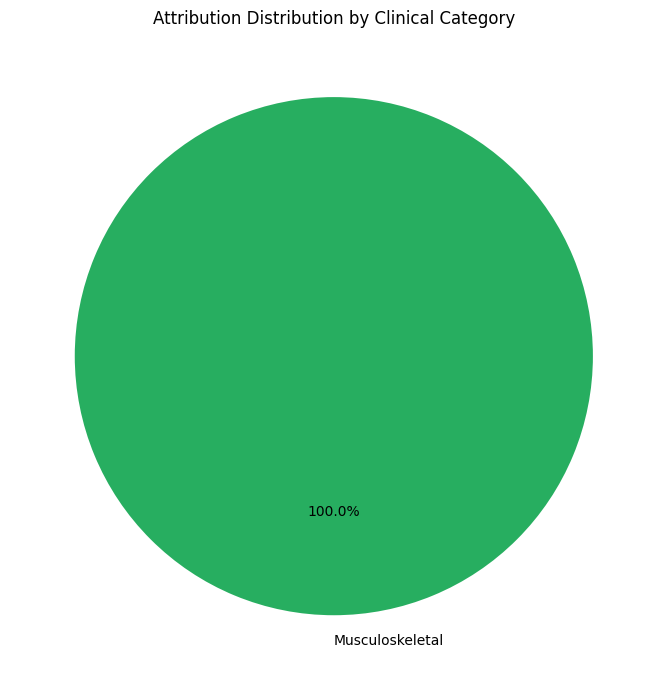

In [10]:
def category_rollup(ig_df):
    if "category" not in ig_df.columns:
        ig_df["category"] = ig_df["concept_id"].map(
            lambda cid: CONCEPT_CATEGORY.get(cid, "Other"))
    cat_df = (ig_df.groupby("category")["attribution"]
              .agg(["sum", "mean", "count"])
              .reset_index()
              .sort_values("sum", ascending=False))
    cat_df.columns = ["category", "total_attribution", "mean_attribution", "n_concepts"]
    total = cat_df["total_attribution"].sum()
    cat_df["pct_contribution"] = 100 * cat_df["total_attribution"] / (total + 1e-9)
    return cat_df


if len(true_pos_idx) > 0:
    pi     = true_pos_idx[0]
    ig_df  = attribute_patient_sequence(pi, baseline_type="both")
    cat_df = category_rollup(ig_df)
    print(f"Clinical category roll-up — TP patient {pi}:")
    print(cat_df.to_string(index=False))

    fig, ax = plt.subplots(figsize=(7, 7))
    colors_pie = {"Cardiovascular": "#c0392b", "Metabolic": "#f39c12",
                  "Respiratory": "#3498db", "Neurological": "#9b59b6",
                  "Musculoskeletal": "#27ae60", "Other": "#95a5a6"}
    pie_colors = [colors_pie.get(c, "#95a5a6") for c in cat_df["category"]]
    ax.pie(cat_df["total_attribution"], labels=cat_df["category"],
           autopct="%1.1f%%", colors=pie_colors, startangle=90)
    ax.set_title("Attribution Distribution by Clinical Category")
    plt.tight_layout()
    plt.savefig(PLOTS / "category_rollup.png", dpi=220, bbox_inches="tight")
    plt.show()

## 5G. Temporal Attribution Decomposition

Temporal attribution decomposition (across TP patients):
period      mean       std
 early 43.294586 11.079440
middle 32.315971 10.422408
recent 74.628386 32.978336


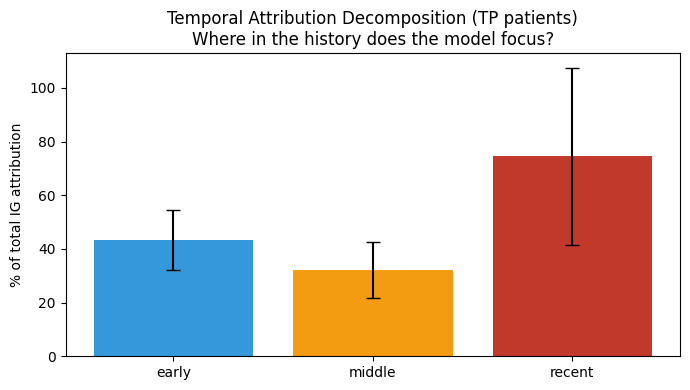

In [11]:
def temporal_decomposition(ig_df):
    if ig_df.empty:
        return pd.DataFrame()
    positions = ig_df["position"].values
    n         = len(positions)
    third     = max(1, n // 3)
    ig_sorted = ig_df.sort_values("position")
    ig_sorted = ig_sorted.copy()
    ig_sorted["period"] = "middle"
    ig_sorted.iloc[:third, ig_sorted.columns.get_loc("period")] = "early"
    ig_sorted.iloc[-third:, ig_sorted.columns.get_loc("period")] = "recent"
    period_df = (ig_sorted.groupby("period")["attribution"]
                 .agg(["sum", "mean", "count"]).reset_index())
    period_df.columns = ["period", "total_attr", "mean_attr", "n_events"]
    total = period_df["total_attr"].sum()
    period_df["pct"] = 100 * period_df["total_attr"] / (total + 1e-9)
    order = {"early": 0, "middle": 1, "recent": 2}
    period_df["_o"] = period_df["period"].map(order)
    return period_df.sort_values("_o").drop(columns="_o")


all_temporal = []
for pi in true_pos_idx[:min(50, len(true_pos_idx))]:
    ig_df = attribute_patient_sequence(pi, baseline_type="both")
    td = temporal_decomposition(ig_df)
    if not td.empty:
        td["patient_idx"] = pi
        all_temporal.append(td)

if all_temporal:
    agg_temporal = pd.concat(all_temporal)
    summary_temporal = (agg_temporal.groupby("period")["pct"]
                        .agg(["mean", "std"]).reset_index())
    order = {"early": 0, "middle": 1, "recent": 2}
    summary_temporal["_o"] = summary_temporal["period"].map(order)
    summary_temporal = summary_temporal.sort_values("_o").drop(columns="_o")
    print("Temporal attribution decomposition (across TP patients):")
    print(summary_temporal.to_string(index=False))

    fig, ax = plt.subplots(figsize=(7, 4))
    colors_t = {"early": "#3498db", "middle": "#f39c12", "recent": "#c0392b"}
    ax.bar(summary_temporal["period"], summary_temporal["mean"],
           yerr=summary_temporal["std"],
           color=[colors_t[p] for p in summary_temporal["period"]],
           capsize=5)
    ax.set_ylabel("% of total IG attribution")
    ax.set_title("Temporal Attribution Decomposition (TP patients)\n"
                 "Where in the history does the model focus?")
    plt.tight_layout()
    plt.savefig(PLOTS / "temporal_decomposition.png", dpi=220, bbox_inches="tight")
    plt.show()

## Summary of v5 Compatibility Changes

| Component       | Was                                    | Now                                             |
|:-----------------------|:-----------------------|:-----------------------|
| Config loading  | `Config(**_cfg_raw)` crashes           | Filter to known fields + override from artefact |
| Time encoding   | `ContinuousTimeEmbedding` (single sin) | `Time2Vec` (8 periodic + 1 linear)              |
| GAT encoder     | `conv1`/`conv2` hardcoded              | `ModuleList(GAT_LAYERS)`                        |
| Patient pooling | `recency_alpha` weighted-mean          | `SequenceAttention` (CLS-query MHA)             |
| IG wrapper      | Used `model.recency_alpha`             | Uses `model.seq_attn`                           |
| Model init      | `CardioGNN(..., heads, dropout)`       | Adds `gat_layers`, `seq_attn_heads`             |
| `DEMO_test`     | `zeros(N, 0)` crash                    | `zeros(N, max(DEMO_DIM,1))`                     |
| `torch.load`    | Missing arg                            | `weights_only=False`                            |